
RQ2 TABLE:

                   AUC
Logistic      0.529958
RandomForest  0.959627
SVM           0.807604


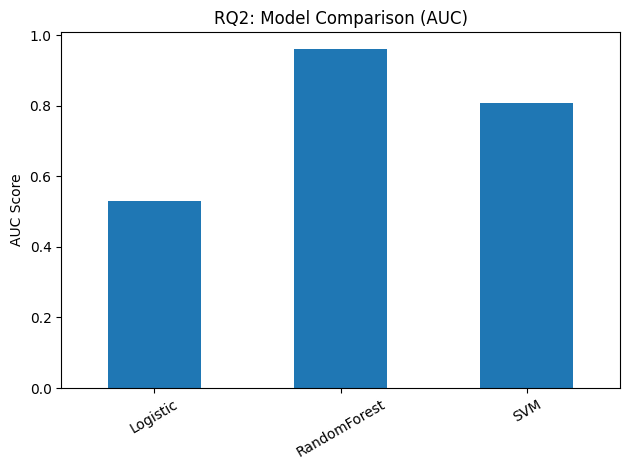


Saved in outputs/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import roc_auc_score


# =========================
# OUTPUT FOLDER
# =========================
os.makedirs("outputs", exist_ok=True)


# =========================
# LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")
df.replace('?', np.nan, inplace=True)


# =========================
# SPLIT
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# DETECT COLUMNS
# =========================
cat_cols = X.select_dtypes(include=['str']).columns
if len(cat_cols) == 0:
    cat_cols = X.select_dtypes(include=['str']).columns

num_cols = X.columns.difference(cat_cols)


# =========================
# PREPROCESSING
# =========================
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)

X = StandardScaler().fit_transform(X)


# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# MODELS
# =========================
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)

    # multiclass safe AUC
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    results[name] = auc


# =========================
# TABLE
# =========================
df_out = pd.DataFrame.from_dict(
    results, orient='index', columns=["AUC"]
)

df_out.to_csv("outputs/RQ2_table.csv")

print("\nRQ2 TABLE:\n")
print(df_out)


# =========================
# FIGURE
# =========================
plt.figure()

df_out["AUC"].plot(kind="bar")

plt.title("RQ2: Model Comparison (AUC)")
plt.ylabel("AUC Score")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("outputs/RQ2_figure.pdf")

plt.show()


print("\nSaved in outputs/")